# Initialization

## Package Imports

In [ ]:
import sklearn
import pandas as pd
import numpy as np
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tabulate import tabulate

import warnings
from sklearn.exceptions import ConvergenceWarning

## Mount Drive

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Constants

In [ ]:
SEED = 102800
ROCK_COUNT = 480

## Error Handling

In [ ]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

## Data Set Import

In [ ]:
dirPath = "/content/drive/MyDrive/CSCI-B 556: Applied ML/B556_Raw_Data/Homework 2/"
rockLabels = pd.read_excel(dirPath + "aggregateRockData.xlsx", header=None).iloc[0:480,1]

In [ ]:
rockAttributes = pd.read_csv(dirPath + "feature_presence540.txt", delim_whitespace=True, header=None).iloc[0:480,3:14]
headers =  ["Angular.Fragments",
            "Rounded.Fragments",
            "Straight.Stripes",
            "Curved.Stripes",
            "Physical.Layers",
            "Veins",
            "Oily/Shimmery.Texture",
            "Splotchy.Texture",
            "Single.Translucent.Crystal",
            "Multiple.Cubic.Crystals",
            "Sandy.Texture"]
rockAttributes.columns = headers

/tmp/ipython-input-2665611824.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  rockAttributes = pd.read_csv(dirPath + "feature_presence540.txt", delim_whitespace=True, header=None).iloc[0:480,3:14]


In [ ]:
humanClassification = pd.read_csv(dirPath + "trialData.csv")

# Part 1
Display the statistical values for each of the attributes, along with visualizations (e.g., histogram) of the distributions for each attribute. Are there any attributes that might require special treatment? If so, what special treatment might they require? [2 points]

In [ ]:
rockAttributes.head()

,Angular.Fragments,Rounded.Fragments,Straight.Stripes,Curved.Stripes,Physical.Layers,Veins,Oily/Shimmery.Texture,Splotchy.Texture,Single.Translucent.Crystal,Multiple.Cubic.Crystals,Sandy.Texture
0,0.20,0.15,0.00,0.0,0.00,0.05,0.0,0.30,0.0,0.00,0.10
1,0.65,0.15,0.00,0.0,0.05,0.00,0.0,0.10,0.0,0.05,0.05
2,0.60,0.00,0.00,0.0,0.05,0.00,0.0,0.35,0.0,0.00,0.05
3,0.10,0.85,0.00,0.0,0.05,0.00,0.0,0.10,0.0,0.00,0.10
4,0.35,0.80,0.00,0.0,0.00,0.00,0.0,0.10,0.0,0.00,0.05


In [ ]:
rockAttributes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Angular.Fragments           480 non-null    object 
 1   Rounded.Fragments           480 non-null    object 
 2   Straight.Stripes            480 non-null    object 
 3   Curved.Stripes              480 non-null    float64
 4   Physical.Layers             480 non-null    float64
 5   Veins                       480 non-null    float64
 6   Oily/Shimmery.Texture       480 non-null    float64
 7   Splotchy.Texture            480 non-null    float64
 8   Single.Translucent.Crystal  480 non-null    float64
 9   Multiple.Cubic.Crystals     480 non-null    float64
 10  Sandy.Texture               480 non-null    float64
dtypes: float64(8), object(3)
memory usage: 41.4+ KB


In [ ]:
type(rockAttributes.iloc[0,0])

str

Pandas has interpreted the first three columns as strings despite them containing only numeric values. This must be corrected.

In [ ]:
rockAttributes = rockAttributes.apply(pd.to_numeric, errors="coerce")

In [ ]:
rockAttributes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Angular.Fragments           480 non-null    float64
 1   Rounded.Fragments           480 non-null    float64
 2   Straight.Stripes            480 non-null    float64
 3   Curved.Stripes              480 non-null    float64
 4   Physical.Layers             480 non-null    float64
 5   Veins                       480 non-null    float64
 6   Oily/Shimmery.Texture       480 non-null    float64
 7   Splotchy.Texture            480 non-null    float64
 8   Single.Translucent.Crystal  480 non-null    float64
 9   Multiple.Cubic.Crystals     480 non-null    float64
 10  Sandy.Texture               480 non-null    float64
dtypes: float64(11)
memory usage: 41.4 KB


After conversion, no values were treated as NaN.

In [ ]:
rockAttributes.describe()

,Angular.Fragments,Rounded.Fragments,Straight.Stripes,Curved.Stripes,Physical.Layers,Veins,Oily/Shimmery.Texture,Splotchy.Texture,Single.Translucent.Crystal,Multiple.Cubic.Crystals,Sandy.Texture
count,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000
mean,0.084479,0.080208,0.067729,0.042292,0.165146,0.052396,0.144479,0.141458,0.031667,0.025104,0.119854
std,0.193996,0.197648,0.194792,0.160970,0.216635,0.102676,0.265689,0.168222,0.135647,0.112153,0.173149
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.100000,0.000000,0.000000,0.100000,0.000000,0.000000,0.050000
75%,0.050000,0.050000,0.000000,0.000000,0.212500,0.050000,0.100000,0.200000,0.000000,0.000000,0.150000
max,1.000000,1.000000,1.000000,1.000000,0.950000,0.900000,1.000000,0.950000,1.000000,1.000000,1.000000


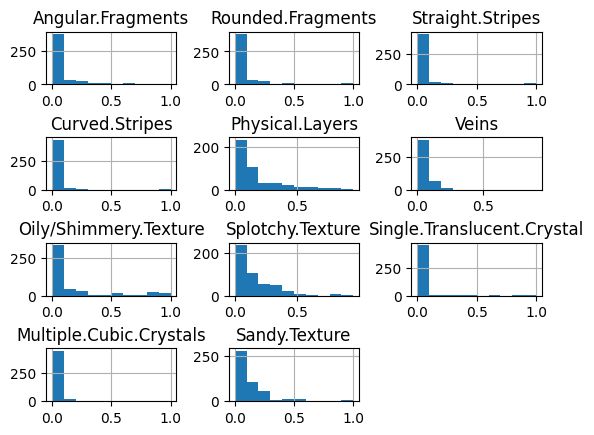

In [ ]:
rockAttributes.hist(
    layout = (4,3)
)
plt.subplots_adjust(wspace=0.4, hspace = 1.0)
plt.show()

Per the assignment specs, there are 480 data points across 11 attributes. All are complete (no NA). However, because each attribute is a frequency of occurence in a sample, they are all heavily skewed toward 0.0, i.e. the attribute's absence. This should not affect the regression but is noteworthy enough to mention.

## Addendum: Experimenting with Normalization
I want to experiment with methods of reducing the skew.

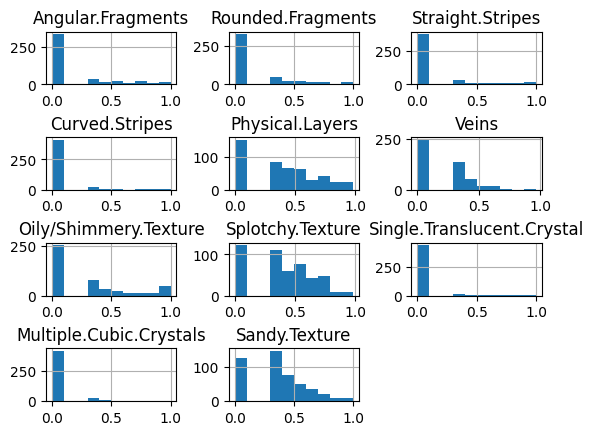

In [ ]:
rootRockAttributes = rockAttributes.apply(lambda x: np.pow(x,1/3))
rootRockAttributes.hist(
    layout = (4,3)
)
plt.subplots_adjust(wspace=0.4, hspace = 1.0)
plt.show()

For Physical Layers, Splotchy Texture, and Sandy Texture, the cube root seems to have a great effect in increasing the variability of the data. I am going to test these after taking the correlations with the unmodified data to see if I can improve the model.

# Part 2
Analyze and discuss the relationships between the data attributes and between the data attributes and labels. This involves computing the Pearson Correlation Coefficient (PCC) and generating scatter plots. [3 points]

In [ ]:
rockAttributes.corr()

,Angular.Fragments,Rounded.Fragments,Straight.Stripes,Curved.Stripes,Physical.Layers,Veins,Oily/Shimmery.Texture,Splotchy.Texture,Single.Translucent.Crystal,Multiple.Cubic.Crystals,Sandy.Texture
Angular.Fragments,1.000000,0.250326,-0.133497,-0.103118,-0.225362,-0.123902,-0.150316,0.063420,-0.087195,-0.018756,-0.165639
Rounded.Fragments,0.250326,1.000000,-0.123095,-0.083384,-0.235652,-0.141425,-0.140435,0.005265,-0.092404,-0.041817,-0.136152
Straight.Stripes,-0.133497,-0.123095,1.000000,0.196752,-0.026329,0.042965,-0.105445,-0.135787,-0.025440,-0.069152,0.112303
Curved.Stripes,-0.103118,-0.083384,0.196752,1.000000,-0.134700,0.045330,-0.070313,-0.116348,-0.056443,-0.056908,-0.071011
Physical.Layers,-0.225362,-0.235652,-0.026329,-0.134700,1.000000,0.061391,0.184191,-0.295079,-0.102496,-0.131038,-0.041839
Veins,-0.123902,-0.141425,0.042965,0.045330,0.061391,1.000000,-0.095940,0.040470,-0.007707,-0.089083,-0.054820
Oily/Shimmery.Texture,-0.150316,-0.140435,-0.105445,-0.070313,0.184191,-0.095940,1.000000,-0.224798,-0.018165,-0.037376,-0.315414
Splotchy.Texture,0.063420,0.005265,-0.135787,-0.116348,-0.295079,0.040470,-0.224798,1.000000,-0.065659,-0.073539,-0.166148
Single.Translucent.Crystal,-0.087195,-0.092404,-0.025440,-0.056443,-0.102496,-0.007707,-0.018165,-0.065659,1.000000,0.115054,-0.134821
Multiple.Cubic.Crystals,-0.018756,-0.041817,-0.069152,-0.056908,-0.131038,-0.089083,-0.037376,-0.073539,0.115054,1.000000,-0.123013


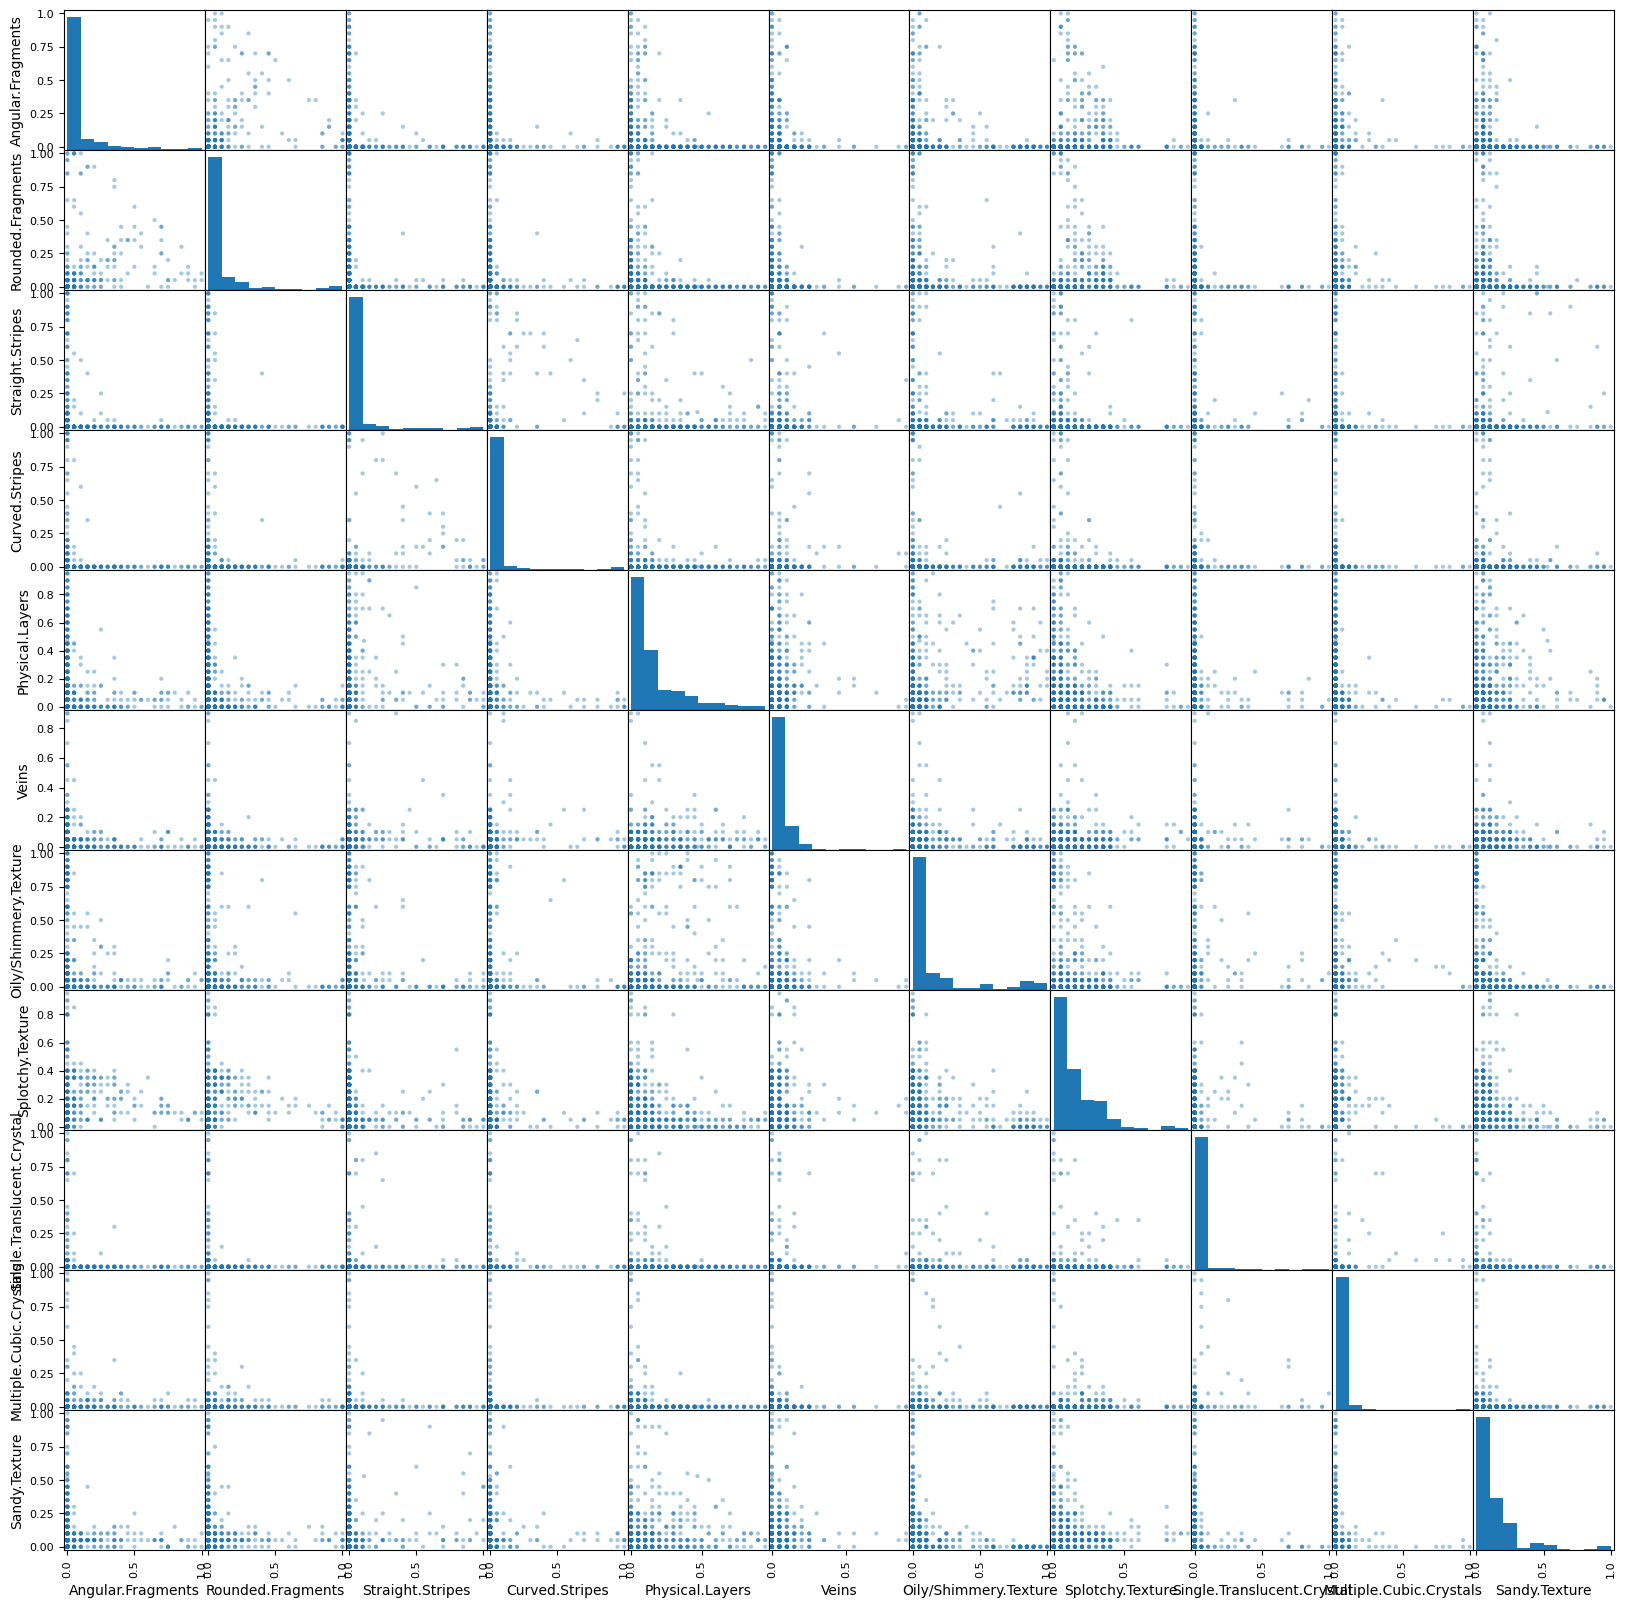

In [ ]:
pd.plotting.scatter_matrix(rockAttributes, alpha=0.4, figsize=(20, 20));

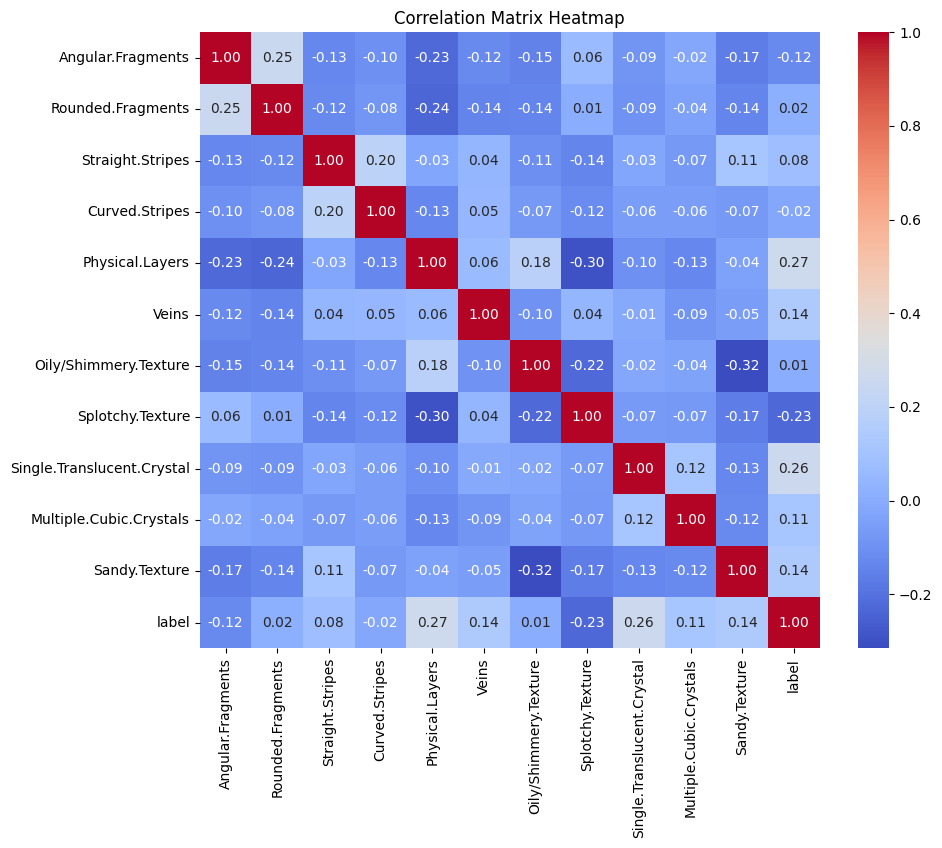

In [ ]:
plt.figure(figsize=(10, 8))
temp = rockAttributes.copy()
temp.insert(len(temp.columns),"label", rockLabels)
sns.heatmap(temp.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

There are not particularly strong correlations between any two attributes. The strongest is -0.32 between *Sandy Texture* and *Oily/Shimmery Texture*, which on some level makes sense given they are distinct if apparently overlapping in a single sample textures. The weakest correlation is *Veins* and *Single Translucent Crystal* at -0.01, i.e. effectively uncorrelated.



As far as correlations with the label, the three strongest are *Physical Layers* (0.27), *Single Translucent Crystal* (0.26), and *Splotchy Texture* (-0.23).

## Experimenting with normalization

In [ ]:
adjRockAttributes = rockAttributes.copy()
cols_to_root = [4,7,10]
adjRockAttributes.iloc[:, cols_to_root] = rockAttributes.iloc[:, cols_to_root].apply(lambda x: np.pow(x, 1/3))

array([[<Axes: title={'center': 'Angular.Fragments'}>,
        <Axes: title={'center': 'Rounded.Fragments'}>,
        <Axes: title={'center': 'Straight.Stripes'}>],
       [<Axes: title={'center': 'Curved.Stripes'}>,
        <Axes: title={'center': 'Physical.Layers'}>,
        <Axes: title={'center': 'Veins'}>],
       [<Axes: title={'center': 'Oily/Shimmery.Texture'}>,
        <Axes: title={'center': 'Splotchy.Texture'}>,
        <Axes: title={'center': 'Single.Translucent.Crystal'}>],
       [<Axes: title={'center': 'Multiple.Cubic.Crystals'}>,
        <Axes: title={'center': 'Sandy.Texture'}>, <Axes: >]],
      dtype=object)

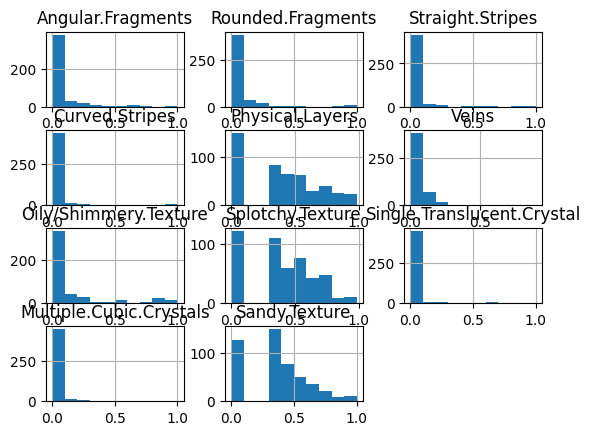

In [ ]:
adjRockAttributes.hist()

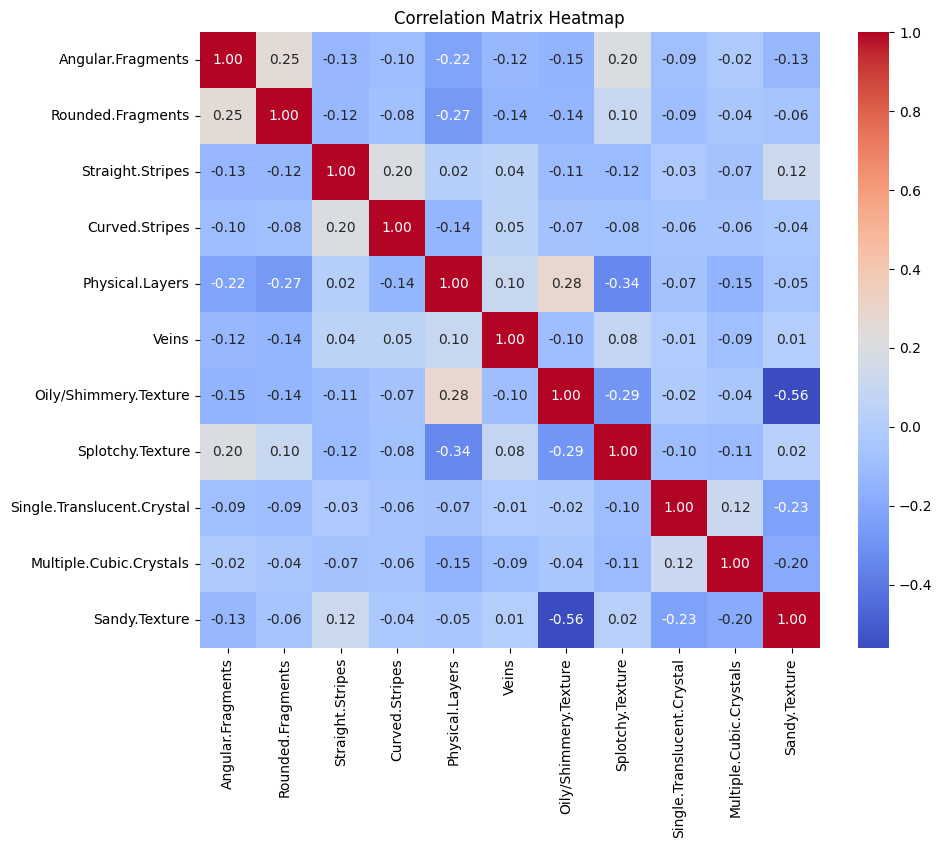

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(adjRockAttributes.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

Interestingly, this did improve the correlations markedly. For instance, using the cube root, the correlation between *Sandy Texture* and *Oily/Shimmery Texture* is now -0.56 as opposed to the original -0.32.

When experimenting with this normalized data, the RMSE actually got worse for the model. Thus, I am leaving it alone for now.

# Part 3
For training data, use token numbers 7-16, for validation 4 to 6, and for testing 1 to 3 (each of the 30 rock subtypes has 16 token numbers). [2 points]

In [ ]:
rockAtt_tokens = pd.read_csv(dirPath + "feature_presence540.txt", sep='\s+', header=None).iloc[0:480,2:14]
rockAtt_tokens = rockAtt_tokens.apply(pd.to_numeric, errors="coerce")
rockAtt_tokens.columns = ["token"] + headers
rockAtt_tokens["Label"] = rockLabels

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-4084747045.py:1: SyntaxWarning: invalid escape sequence '\s'
  rockAtt_tokens = pd.read_csv(dirPath + "feature_presence540.txt", sep='\s+', header=None).iloc[0:480,2:14]


In [ ]:
rockAtt_train = rockAtt_tokens[rockAtt_tokens.iloc[:,0].between(7,16)]
rockAtt_val = rockAtt_tokens[rockAtt_tokens.iloc[:,0].between(4,6)]
rockAtt_test = rockAtt_tokens[rockAtt_tokens.iloc[:,0].between(1,3)]

In [ ]:
rockAtt_train_labels = rockAtt_train["Label"]
rockAtt_val_labels = rockAtt_val["Label"]
rockAtt_test_labels = rockAtt_test["Label"]

rockAtt_train_data = rockAtt_train.drop(columns=["Label"])
rockAtt_val_data = rockAtt_val.drop(columns=["Label"])
rockAtt_test_data = rockAtt_test.drop(columns=["Label"])

# Part 4
Train different classifiers and tweak the hyperparameters to improve performance (you can use the grid search if you want or manually try different values). Report training, validation and testing performance (classification accuracy, precision, recall and F1 score) and discuss the impact of the hyperparameters (use markdown cells in Jupyter Notebook to clearly indicate each solution):

In [ ]:
# Scales data such that x̄ = 0, σ = 1 using StandardScaler
def scale_data(X_train, X_test):
  scaler = StandardScaler()
  scaler.fit(X_train)

  X_train_scaled = scaler.transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  # convert back to pd DF and keep the feature names and row indices
  X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
  X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
  return X_train_scaled, X_test_scaled

In [ ]:
rockAtt_t_data_scaled, rockAtt_v_data_scaled = scale_data(rockAtt_train_data.iloc[:,1:], rockAtt_val_data.iloc[:,1:])

In [ ]:
rockAtt_t_data_scaled.head()

,Angular.Fragments,Rounded.Fragments,Straight.Stripes,Curved.Stripes,Physical.Layers,Veins,Oily/Shimmery.Texture,Splotchy.Texture,Single.Translucent.Crystal,Multiple.Cubic.Crystals,Sandy.Texture
6,2.912593,2.133487,-0.341236,-0.241542,-0.765551,-0.523318,-0.545129,-0.213679,-0.24995,-0.223538,-0.405002
7,-0.450081,-0.416497,-0.341236,-0.241542,-0.765551,-0.523318,-0.545129,0.385422,-0.24995,-0.223538,0.429862
8,1.360590,1.113493,-0.341236,-0.241542,-0.765551,-0.523318,-0.545129,0.984522,-0.24995,-0.223538,-0.405002
9,1.101922,0.603496,-0.341236,-0.241542,-0.765551,-0.523318,-0.545129,0.085871,-0.24995,-0.223538,-0.126714
10,3.688594,-0.161499,-0.341236,-0.241542,-0.320204,-0.523318,-0.545129,-0.213679,-0.24995,-0.223538,0.151574


In [ ]:
def run_model(model):
  model.fit(rockAtt_t_data_scaled, rockAtt_train_labels)
  y_pred = model.predict(rockAtt_v_data_scaled)
  rmse = root_mean_squared_error(rockAtt_val_labels, y_pred)
  print(f"The model's RMSE is {rmse:,.4f}")

In [ ]:
def print_model_results(model_data):
  min = model_data.loc[model_data["RMSE"].idxmin()]
  max = model_data.loc[model_data["RMSE"].idxmax()]
  print(f"Minimum RMSE Hyperparameters:\n{min}\n\nMaximum RMSE Hyperparameters:\n{max}")

In [ ]:
def test_model(model, name="classifier"):
  train_scaled, test_scaled = scale_data(rockAtt_train_data.iloc[:,1:], rockAtt_test_data.iloc[:,1:])
  model.fit(train_scaled, rockAtt_train_labels)
  y_pred = model.predict(test_scaled)

  test_rmse = root_mean_squared_error(rockAtt_test_labels, y_pred)
  accuracy = accuracy_score(rockAtt_test_labels, y_pred)
  precision = precision_score(rockAtt_test_labels, y_pred, average='weighted')
  recall = recall_score(rockAtt_test_labels, y_pred, average='weighted')
  f1 = f1_score(rockAtt_test_labels, y_pred, average='weighted')

  print(f"Model:\t{name}")
  print(f"Test RMSE:\t{test_rmse:,.4f}")
  print(f"Accuracy:\t{accuracy:,.4f}")
  print(f"Precision:\t{precision:,.4f}")
  print(f"Recall:\t\t{recall:,.4f}")
  print(f"F1 Score:\t{f1:,.4f}")
  print()

## Multinomial Logistic Regression (Softmax Regression)
Hyperparameters to explore: C, solver, max number of iterations. [10 points]

### Base Model

In [ ]:

def lr_model(max_iter = 1000, solver="lbfgs", C=1.0):
   return(LogisticRegression(
       random_state=SEED,
       max_iter=max_iter,
       solver=solver,
       C=C,
   ))

run_model(lr_model())

The model's RMSE is 0.8563


### Hyperparameter Tuning
Iteration on all parameters, with minimum RMSE used for testing

In [ ]:
def lr_hyperparameter_tuning(
  iterations = [100,1000,5000,10000],
  solvers = ["lbfgs", "sag", "saga"], # liblinear is not multinomial
  Cs = [0.01, 0.1, 1, 10, 100]):

  data = pd.DataFrame(columns=["Iteration", "Solver", "C", "RMSE"])

  index = 0
  for i in iterations:
    for s in solvers:
      for c in Cs:
        model = lr_model(max_iter=i, solver=s, C=c)
        model.fit(rockAtt_t_data_scaled, rockAtt_train_labels)
        y_pred = model.predict(rockAtt_v_data_scaled)
        rmse = root_mean_squared_error(rockAtt_val_labels, y_pred)

        data.loc[index] = [i, s, c, rmse]
        index += 1

  return data


In [ ]:
lr_hp_data = lr_hyperparameter_tuning()
# print(tabulate(lr_hp_data, headers = ["Iterations", "Solver", "C-Value", "RMSE"]))

In [ ]:
print_model_results(lr_hp_data)

Minimum RMSE Hyperparameters:
Iteration         100
Solver          lbfgs
C                 0.1
RMSE         0.823273
Name: 1, dtype: object

Maximum RMSE Hyperparameters:
Iteration         100
Solver          lbfgs
C                 1.0
RMSE         0.856349
Name: 2, dtype: object


Seeing as 100 iterations was producing the min and max RMSE, I will experiment with even fewer iterations.

In [ ]:
lr_hp_data = lr_hyperparameter_tuning(iterations = [10, 50, 100], solvers = ["lbfgs"], Cs = [0.1])

In [ ]:
print_model_results(lr_hp_data)

Minimum RMSE Hyperparameters:
Iteration          10
Solver          lbfgs
C                 0.1
RMSE         0.823273
Name: 0, dtype: object

Maximum RMSE Hyperparameters:
Iteration          10
Solver          lbfgs
C                 0.1
RMSE         0.823273
Name: 0, dtype: object


Performance hasn't improved, implying it reached a stable minimum quite quickly. I will leave it's parameters here for the prime model.

In [ ]:
prime_lr_model = lr_model(max_iter=10, solver="lbfgs", C=0.1)

## Support Vector Machine (make sure to try using kernels)
Hyperparameters to explore: C, kernel, degree of polynomial kernel, gamma.  [10 points]

### Base Model

In [ ]:
# Define SVM classifier
def svm_model(C=1.0, kernel='rbf', degree=3, gamma='scale'):
  return SVC(kernel=kernel, C=C, gamma=gamma, degree=degree, random_state=SEED, probability=True)

run_model(svm_model())

The model's RMSE is 0.7746


### Hyperparameter Tuning

In [ ]:
def svm_hyperparameter_tuning(
  Cs = [0.01, 0.1, 1, 10, 100],
  kernels = ['linear', 'poly', 'rbf', 'sigmoid'],
  degrees = [3,4,5],
  gammas = [0.01, 0.1, 1, 10, 'scale']):

  data = pd.DataFrame(columns=["C", "Kernel", "Degree", "Gamma", "RMSE"])

  index = 0
  for c in Cs:
    for k in kernels:
      for d in degrees:
        for g in gammas:
          model = svm_model(C=c, kernel=k, degree=d, gamma=g)
          model.fit(rockAtt_t_data_scaled, rockAtt_train_labels)
          y_pred = model.predict(rockAtt_v_data_scaled)
          rmse = root_mean_squared_error(rockAtt_val_labels, y_pred)

          data.loc[index] = [c, k, d, g, rmse]
          index += 1

  return data

In [ ]:
svm_hp_data = svm_hyperparameter_tuning()

In [ ]:
# print(tabulate(svm_hp_data, headers = ["C-Value", "Kernel", "Degrees", "Gamma", "RMSE"]))

In [ ]:
print_model_results(svm_hp_data)

Minimum RMSE Hyperparameters:
C             0.01
Kernel        poly
Degree           3
Gamma           10
RMSE      0.760117
Name: 18, dtype: object

Maximum RMSE Hyperparameters:
C             0.01
Kernel        poly
Degree           5
Gamma         0.01
RMSE      1.286684
Name: 25, dtype: object


Since this tuning has used the minimum C and maximum Gamma, I will continue tuning with additional values for these parameters.

In [ ]:
svm_hp_data = svm_hyperparameter_tuning(Cs = [0.0001, 0.001, 0.01], kernels = ["poly"], degrees = [3, 4], gammas = [10, 20, 50, 100])

In [ ]:
print_model_results(svm_hp_data)

Minimum RMSE Hyperparameters:
C            0.001
Kernel        poly
Degree           3
Gamma           20
RMSE      0.752773
Name: 9, dtype: object

Maximum RMSE Hyperparameters:
C           0.0001
Kernel        poly
Degree           4
Gamma           10
RMSE      0.912871
Name: 4, dtype: object


This has produced a model with slightly better performance.

In [ ]:
prime_svm_model = svm_model(C=0.001, kernel='poly', degree=3, gamma=20)

## Random Forest Classifier (also analyze feature importance)
Hyperparameters to explore: the number of trees, max depth, the minimum number of samples required to split an internal node, the minimum number of samples required to be at a leaf node. [10 points]

### Base Model

In [ ]:
def rf_model(n=100, max_depth=None, min_samples_split=2, min_samples_leaf=1):
  return RandomForestClassifier(
      n_estimators=n,
      max_depth=max_depth,
      min_samples_split=min_samples_split,
      min_samples_leaf=min_samples_leaf,
      random_state=SEED
  )

run_model(rf_model())

The model's RMSE is 0.8097


### Hyperparameter Tuning

In [ ]:
def rf_hyperparameter_tuning(
  tree_count = [50, 75, 100, 200],
  max_depths = [5, 10, 15, None],
  min_samples_splits = [2, 5, 10],
  min_samples_leafs = [1, 2, 4, 8]):

  data = pd.DataFrame(columns=["Tree.Count", "Max.Depth", "Min.Samples.per.Split", "Min.Samples.per.Leaf", "RMSE"])

  index = 0
  for t in tree_count:
    for d in max_depths:
      for s in min_samples_splits:
        for l in min_samples_leafs:
          model = rf_model(n = t,
                           max_depth = d,
                           min_samples_split = s,
                           min_samples_leaf = l)

          model.fit(rockAtt_t_data_scaled, rockAtt_train_labels)
          y_pred = model.predict(rockAtt_v_data_scaled)
          rmse = root_mean_squared_error(rockAtt_val_labels, y_pred)

          data.loc[index] = [t, d, s, l, rmse]
          index += 1

  return data

In [ ]:
rf_hp_data = rf_hyperparameter_tuning()

In [ ]:
print_model_results(rf_hp_data)

Minimum RMSE Hyperparameters:
Tree.Count               75.000000
Max.Depth                      NaN
Min.Samples.per.Split     2.000000
Min.Samples.per.Leaf      1.000000
RMSE                      0.788811
Name: 84, dtype: float64

Maximum RMSE Hyperparameters:
Tree.Count               50.000000
Max.Depth                 5.000000
Min.Samples.per.Split    10.000000
Min.Samples.per.Leaf      1.000000
RMSE                      0.942809
Name: 8, dtype: float64


There does not appear to be further tuning that can be done on the Random Forest model, so the ideal values from this hyperparameter tuning will be used.

In [ ]:
prime_rf_model = rf_model(n=75, max_depth=None, min_samples_split=2, min_samples_leaf=1)

In [ ]:
feature_imp = (prime_rf_model.fit(rockAtt_t_data_scaled, rockAtt_train_labels)).feature_importances_
for i, header in enumerate(headers):
  print(f"{header}: {feature_imp[i]:,.4f}\n")

Angular.Fragments: 0.0874

Rounded.Fragments: 0.0925

Straight.Stripes: 0.0540

Curved.Stripes: 0.0486

Physical.Layers: 0.1699

Veins: 0.0877

Oily/Shimmery.Texture: 0.1010

Splotchy.Texture: 0.1269

Single.Translucent.Crystal: 0.0675

Multiple.Cubic.Crystals: 0.0298

Sandy.Texture: 0.1348



The feature importances show *Physical Layers* as most important (0.1699) followed by *Sandy Texture* (0.1348) and *Splotchy Texture* (0.1269). The first and last correspond with high correlations with the label in the heatmap, relatively speaking. However, *Sandy Texture* is notable since it was fairly average and in fact below *Single Translucent Crystal* which is of relatively low importance here (0.0675).

I surmise that this importance is due to its correlations with other attributes as opposed to the label directly.

# Part 5
Combine your classifiers into an ensemble and try to outperform each individual classifier on the validation set. Once you have found a good one, try it on the test set. Describe and discuss your findings. [8 points]

## Hard Classifier Ensemble

In [ ]:
hard_voting_model = VotingClassifier(
    estimators=[('lr', prime_lr_model), ('svc', prime_svm_model), ('rf', prime_rf_model)],
    voting='hard'   # 'hard' uses majority vote, 'soft' uses probabilities
)

As a refresher, here are the results for the prime models.

In [ ]:
run_model(prime_lr_model)
run_model(prime_svm_model)
run_model(prime_rf_model)

The model's RMSE is 0.8233
The model's RMSE is 0.7528
The model's RMSE is 0.7888


The ensemble method

In [ ]:
run_model(hard_voting_model)

The model's RMSE is 0.7674


As is perhaps expected, the ensemble performs better than the majority of classifiers. However, the SVM remains the best overall.

Now, to compare it against each individual classifier.

In [ ]:
test_model(hard_voting_model, name = "Ensemble")

Model:	Ensemble
Test RMSE:	0.7528
Accuracy:	0.7000
Precision:	0.7121
Recall:		0.7000
F1 Score:	0.6983



In [ ]:
test_model(prime_lr_model, name = "Logistic Regression")
print()
test_model(prime_svm_model, name = "Support Vector Machine")
print()
test_model(prime_rf_model, name = "Random Forest")

Model:	Logistic Regression
Test RMSE:	0.8097
Accuracy:	0.6444
Precision:	0.6761
Recall:		0.6444
F1 Score:	0.6348


Model:	Support Vector Machine
Test RMSE:	0.7454
Accuracy:	0.6778
Precision:	0.6798
Recall:		0.6778
F1 Score:	0.6736


Model:	Random Forest
Test RMSE:	0.7674
Accuracy:	0.7111
Precision:	0.7138
Recall:		0.7111
F1 Score:	0.7108



The overall trend remains. Interestingly, all models perform better on the test set than the validation set.

In [ ]:
print(f"The average RMSE of the indiviudal models is {np.average([0.8097, 0.7454, 0.7674]):,.4f}")

The average RMSE of the indiviudal models is 0.7742


However, the ensemble performs better than the individual models' average.

As far as the various metrics are concerned, while notable, they are not exceptional (to me) given that there was a floor of 0.33 accuracy due to the three labels. Perhaps learning more about statistics would change my mind regarding that. That the model has relative parity between precision and recall indicates little bias toward any specific label, with equal amounts false negative as false positive.

## Soft Classifier Ensemble

In [ ]:
soft_voting_model = VotingClassifier(
    estimators=[('lr', prime_lr_model), ('svc', prime_svm_model), ('rf', prime_rf_model)],
    voting='soft'   # 'hard' uses majority vote, 'soft' uses probabilities
)

In [ ]:
test_model(soft_voting_model)

Model:	classifier
Test RMSE:	0.7888
Accuracy:	0.6778
Precision:	0.6785
Recall:		0.6778
F1 Score:	0.6761



Curiously, Soft Voting resulted in worse RMSE and worse accuracy compared to Hard Voting. This would imply that one of the models is overconfident in its predictions. Given that Random Forest performed better than the SVM or Logistic Regression, I propose that it must be one of those two.

Addendum: After completing Q2, Logistic Regression seems the likely culprit since the ensemble methods there were falling in line with its statistics perfectly. Why it is so overly (and falsely) confident I presume is due to some form of overfitting.

# Part 6


## A: Better than a human?
Is your method better than a human? Test that by taking human data from trialData.csv. Compute human accuracy on train and test rocks jointly (use only rocks with numbers 1 to 480 and Block number 4 (blocks 1-3 were used for human training, ignore those), use column cat_correct for human categorization accuracy). How does the human accuracy compare to the accuracy of your best model for each model type (softmax regression, SVM, Random Forest, and Ensemble)? [2 points].

In [ ]:
humanClassification = humanClassification[(humanClassification["block"] == 4) & (humanClassification["rocknumber"] <= 480)]

In [ ]:
humanClassification.head()

,subid,block,trial,rocknumber,category,subtype,token,type,catresponse,recresponse,cat_correct,rec_correct
540,A1HUMXQ7SEXD8E,4,541,341,Sedimentary,Breccia,5,StandardTransfer,Sedimentary,Yes,1,0.0
541,A1HUMXQ7SEXD8E,4,542,413,Sedimentary,Micrite,13,NonparentTraining,Sedimentary,Yes,1,1.0
542,A1HUMXQ7SEXD8E,4,543,162,Metamorphic,Amphibolite,2,NonparentTraining,Metamorphic,Yes,1,1.0
543,A1HUMXQ7SEXD8E,4,544,217,Metamorphic,Hornfels,9,StandardTransfer,Sedimentary,Yes,0,0.0
544,A1HUMXQ7SEXD8E,4,545,326,Sedimentary,Bituminous Coal,6,ParentTraining,Sedimentary,Yes,1,1.0


In [ ]:
average = np.average(humanClassification["cat_correct"])
print(f"Human accuracy was {average:,.4f}")

Human accuracy was 0.5984


Human accuracy was lower than any of the models, whether individual or ensemble.

## B: Plot- Human v. Machine
Make a plot with the x-axis showing average human accuracy (values between 0 and 1) and y-axis showing model probability (also values between 0 and 1) for 480 rocks (regardless of whether they were used for train or test). Each rock should be represented with a dot in this plot. [2 points]

### Model Probabilities per Rock

In [ ]:
def label_probability(model):
  ROCK_COUNT = 480

  rockAtt_labels = rockAtt_tokens["Label"]
  rockAtt_data = rockAtt_tokens.drop(columns=["Label"])

  rockAtt_train_scaled, all_scaled = scale_data(rockAtt_train_data.iloc[:,1:], rockAtt_data.iloc[:,1:])

  model.fit(rockAtt_train_scaled, rockAtt_train_labels)
  model_proba = model.predict_proba(all_scaled) # Use the passed in model

  df_results = pd.DataFrame(columns=["real_label", "model_proba"])
  df_results["real_label"] = rockAtt_labels
  df_results["model_proba"] = 0.0

  # Iterate through the actual indices of the DataFrame
  for idx in df_results.index:
    actual_label = df_results.loc[idx, "real_label"]
    # Find the index corresponding to the actual_label in the model_proba columns
    label_index = model.classes_.tolist().index(actual_label)
    rock_probability = model_proba[idx][label_index]

    df_results.loc[idx, "model_proba"] = rock_probability

  return df_results

In [ ]:
lr_proba = label_probability(prime_lr_model)["model_proba"]
svm_proba = label_probability(prime_svm_model)["model_proba"]
rf_proba = label_probability(prime_rf_model)["model_proba"]
ensemble_proba = label_probability(soft_voting_model)["model_proba"]

In [ ]:
lr_proba

,model_proba
0,0.631112
1,0.647098
2,0.741257
3,0.389504
4,0.475576
...,...
475,0.706496
476,0.609218
477,0.512782
478,0.481876


### Human Accuracies per Rock

In [ ]:
def human_accuracy():
  human_acc = pd.Series(name="human_accuracy")

  for i in range(1, ROCK_COUNT+1):
    # Models were 0-indexed while human scores were 1-indexed (discovered in Part C)
    human_acc.loc[i-1] = np.average((humanClassification[humanClassification["rocknumber"] == i])["cat_correct"])

  return human_acc


In [ ]:
human_acc = human_accuracy()

### Plots
ChatGPT was used to generate these plots

In [ ]:
combined_df = pd.DataFrame({
    "Human Accuracy": human_acc,
    "LR Probability": lr_proba,
    "SVM Probability": svm_proba,
    "RF Probability": rf_proba,
    "Ensemble Probability": ensemble_proba
})

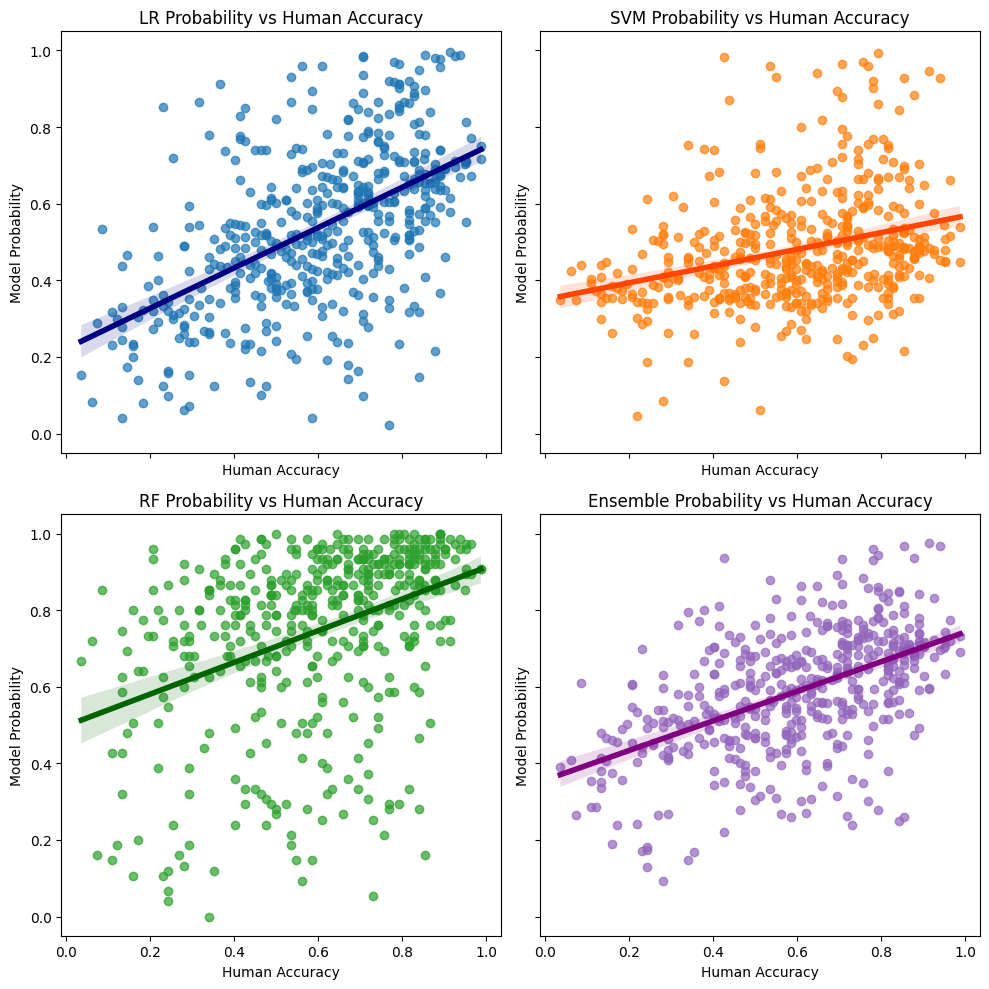

In [ ]:
models = ["LR Probability", "SVM Probability", "RF Probability", "Ensemble Probability"]

plot_colors = ["tab:blue", "tab:orange", "tab:green", "tab:purple"]
line_colors = ["navy", "orangered", "darkgreen", "purple"]

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, model, plot_color, line_color in zip(axes, models, plot_colors, line_colors):
    sns.regplot(
        data=combined_df,
        x="Human Accuracy",
        y=model,
        ax=ax,
        scatter_kws=dict(alpha=0.7, color = plot_color),
        line_kws=dict(color=line_color, linewidth = 4),
        ci=95
    )

    ax.set_title(f"{model} vs Human Accuracy")
    ax.set_xlabel("Human Accuracy")
    ax.set_ylabel("Model Probability")

plt.tight_layout()
plt.show()

## C: Correlation Coefficient
 Compute the correlation coefficient between average human accuracies and model probabilities of the correct class for your best model for each model type (softmax regression, SVM, Random Forest, and Ensemble) for all 480 rocks (so you need to compute four correlation coefficients). Report the p-value for each of the four correlation coefficients. Are the correlations significant? [1 point]

In [ ]:
combined_df.corrwith(combined_df["Human Accuracy"])

,0
Human Accuracy,1.000000
LR Probability,0.537449
SVM Probability,0.308777
RF Probability,0.387844
Ensemble Probability,0.516404


In [ ]:
from scipy.stats import pearsonr

for model in models:
  r, p = pearsonr(combined_df["Human Accuracy"], combined_df[model])
  print(f"The correlation coefficient for {model} is {r:,.4f} with a p-value of {p:,.4f}")

The correlation coefficient for LR Probability is 0.5374 with a p-value of 0.0000
The correlation coefficient for SVM Probability is 0.3088 with a p-value of 0.0000
The correlation coefficient for RF Probability is 0.3878 with a p-value of 0.0000
The correlation coefficient for Ensemble Probability is 0.5164 with a p-value of 0.0000


Given that the p-value is 0.0000 in all four cases and that it was calculated using an inbuilt method as opposed to my own code, yes, I would say they are significant.

# References

This assignment largely built on Homework 1. I referred to Scikit-learn's documentation for the new model methods. However, I relied heavily on ChatGPT for creating the plots. After fooling around with R so much last time, I will try and study the code generated here to be able to create it myself on the next Homework.